### **Part 1 : EDA**

In [1]:
# Imports and Global Configuration

from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

# Reproducibility
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f"Using device: {device} ({torch.cuda.get_device_name(0)})")
else:
    print(f"Using device: {device}")

# Project directories
DATA_DIR = Path("data")
FIGURES_DIR = Path("figures")

DATA_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Fashion-MNIST class names
_temp_dataset = torchvision.datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True
)

CLASS_NAMES = _temp_dataset.classes

print("Classes:", CLASS_NAMES)

Using device: cuda (NVIDIA GeForce RTX 4050 Laptop GPU)


100.0%


Extracting data\FashionMNIST\raw\train-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%
0.7%

Extracting data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%

Extracting data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data\FashionMNIST\raw

Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [2]:
# Load and Split Fashion-MNIST

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load datasets
full_train_dataset = torchvision.datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform
)

# Train / Validation split
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

# DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# Dataset summary
print("=== DATASET SUMMARY ===")
print(f"Training samples   : {len(train_dataset):,}")
print(f"Validation samples : {len(val_dataset):,}")
print(f"Test samples       : {len(test_dataset):,}")
print(f"Image shape        : {full_train_dataset[0][0].shape}")
print(f"Number of classes  : {len(CLASS_NAMES)}")
print(f"Classes            : {CLASS_NAMES}")

=== DATASET SUMMARY ===
Training samples   : 54,000
Validation samples : 6,000
Test samples       : 10,000
Image shape        : torch.Size([1, 28, 28])
Number of classes  : 10
Classes            : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [3]:
# Data Quality Check

print("Data Quality Check\n")

# Use the complete original training dataset for EDA
eda_dataset = full_train_dataset

# Check 1: Missing values
all_imgs = torch.stack([
    eda_dataset[i][0] for i in range(len(eda_dataset))
])

nan_count = torch.isnan(all_imgs).sum().item()

print(
    f"Missing values (NaN)     : {nan_count} "
    f"→ {'None' if nan_count == 0 else '⚠️ Found'}"
)

# Check 2: Pixel range after normalization
print(
    f"Pixel value range         : "
    f"[{all_imgs.min():.3f}, {all_imgs.max():.3f}] "
    f"→ Normalized [-1, 1]"
)

# Check 3: Class balance
labels = [
    eda_dataset[i][1] for i in range(len(eda_dataset))
]

counts = Counter(labels)

min_count = min(counts.values())
max_count = max(counts.values())

print(f"Min samples per class     : {min_count:,}")
print(f"Max samples per class     : {max_count:,}")
print(
    f"Class imbalance ratio     : {max_count/min_count:.2f} "
    f"→ {'Perfectly balanced' if max_count == min_count else 'Imbalanced'}"
)

# Check 4: Image shape consistency
shapes = {
    eda_dataset[i][0].shape
    for i in range(100)
}

print(
    f"Image shapes (100 checked): {shapes} "
    f"→ {'Consistent' if len(shapes) == 1 else '⚠️ Inconsistent'}"
)

print("\nData quality check complete.")

Data Quality Check

Missing values (NaN)     : 0 → None
Pixel value range         : [-1.000, 1.000] → Normalized [-1, 1]
Min samples per class     : 6,000
Max samples per class     : 6,000
Class imbalance ratio     : 1.00 → Perfectly balanced
Image shapes (100 checked): {torch.Size([1, 28, 28])} → Consistent

Data quality check complete.


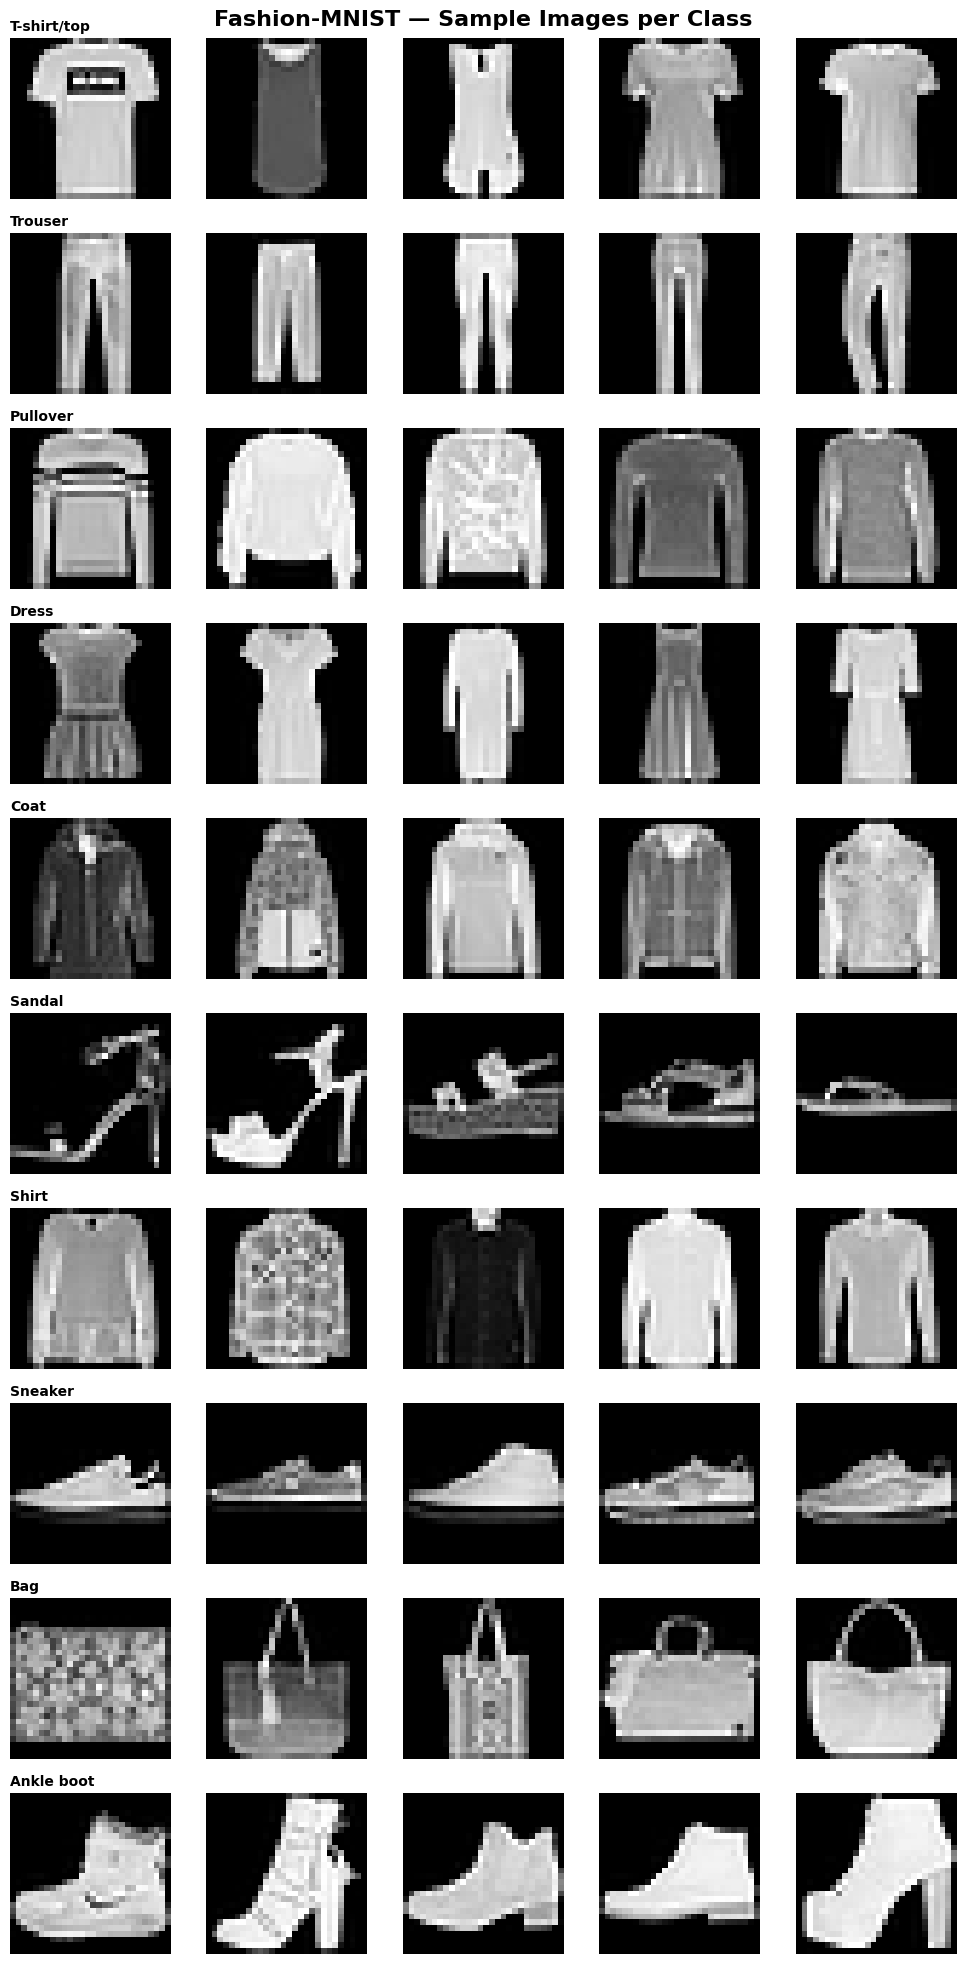

 Saved: figures/sample_images.png


In [4]:
# EDA Figure 1: Sample images per class

fig, axes = plt.subplots(10, 5, figsize=(10, 20))
fig.suptitle("Fashion-MNIST — Sample Images per Class", fontsize=16, fontweight='bold')

for class_idx in range(10):
    # Get 5 samples of this class
    indices = [i for i, (_, label) in enumerate(eda_dataset) if label == class_idx][:5]
    for col, idx in enumerate(indices):
        img, _ = eda_dataset[idx]
        img = img.squeeze().numpy()
        axes[class_idx, col].imshow(img, cmap='gray')
        axes[class_idx, col].axis('off')
        if col == 0:
            axes[class_idx, col].set_title(CLASS_NAMES[class_idx], 
                                           fontsize=10, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig('figures/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: figures/sample_images.png")

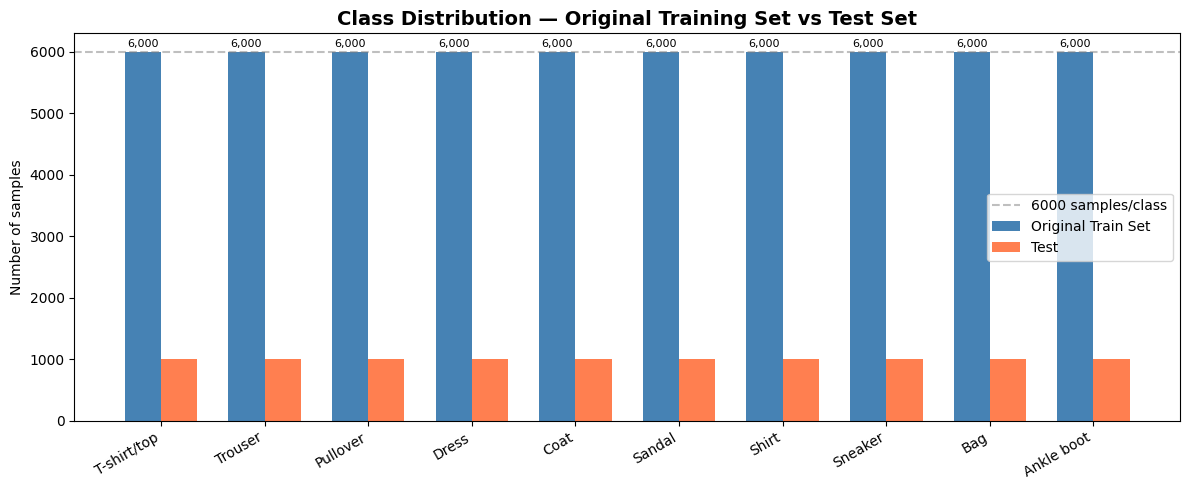

 Saved: figures/class_distribution.png


In [5]:
# EDA Figure 2: Class distribution

labels_train = [label for _, label in full_train_dataset]
labels_test  = [label for _, label in test_dataset]

counts_train = Counter(labels_train)
counts_test  = Counter(labels_test)

x = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, [counts_train[i] for i in range(10)], 
               width, label='Original Train Set', color='steelblue')
bars2 = ax.bar(x + width/2, [counts_test[i]  for i in range(10)], 
               width, label='Test',  color='coral')

ax.set_title('Class Distribution — Original Training Set vs Test Set', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('Number of samples')
ax.axhline(y=6000, color='gray', linestyle='--', alpha=0.5, label='6000 samples/class')
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: figures/class_distribution.png")

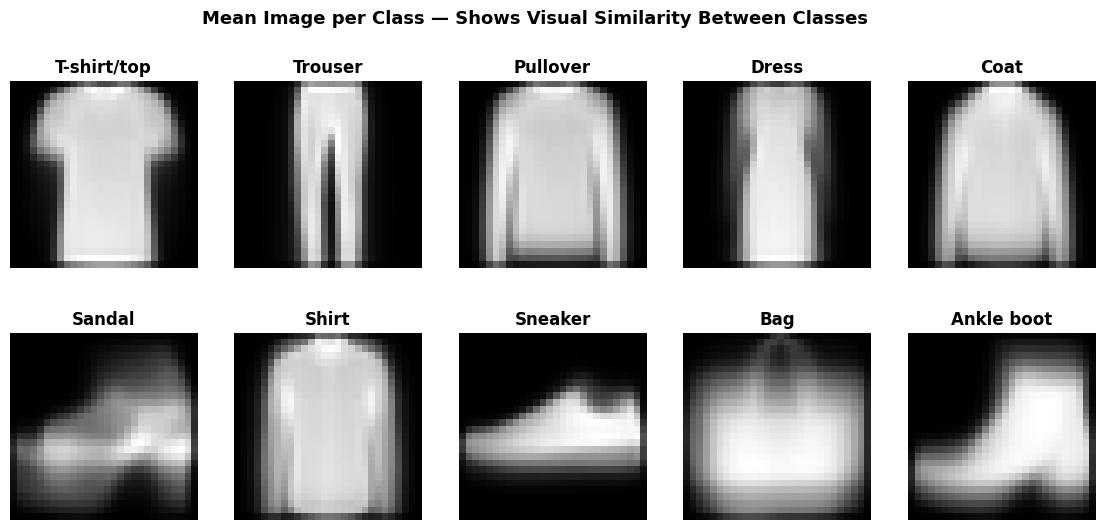

 Saved: figures/mean_images.png


In [6]:
# EDA Figure 3: Mean image per class (very insightful!)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Mean Image per Class — Shows Visual Similarity Between Classes", 
             fontsize=13, fontweight='bold')

for class_idx in range(10):
    imgs = [eda_dataset[i][0].squeeze().numpy() 
            for i in range(len(eda_dataset)) 
            if eda_dataset[i][1] == class_idx]
    mean_img = np.mean(imgs, axis=0)
    
    row, col = divmod(class_idx, 5)
    axes[row, col].imshow(mean_img, cmap='gray')
    axes[row, col].set_title(CLASS_NAMES[class_idx], fontweight='bold')
    axes[row, col].axis('off')

#plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.savefig('figures/mean_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: figures/mean_images.png")

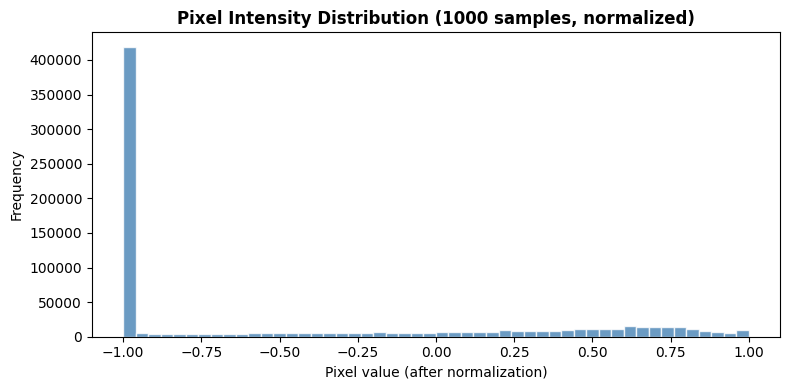

 Saved: figures/pixel_distribution.png


In [7]:
# EDA Figure 4: Pixel intensity distribution

sample_imgs = [eda_dataset[i][0].numpy().flatten() for i in range(1000)]
all_pixels = np.concatenate(sample_imgs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_pixels, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('Pixel Intensity Distribution (1000 samples, normalized)', fontweight='bold')
ax.set_xlabel('Pixel value (after normalization)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('figures/pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: figures/pixel_distribution.png")

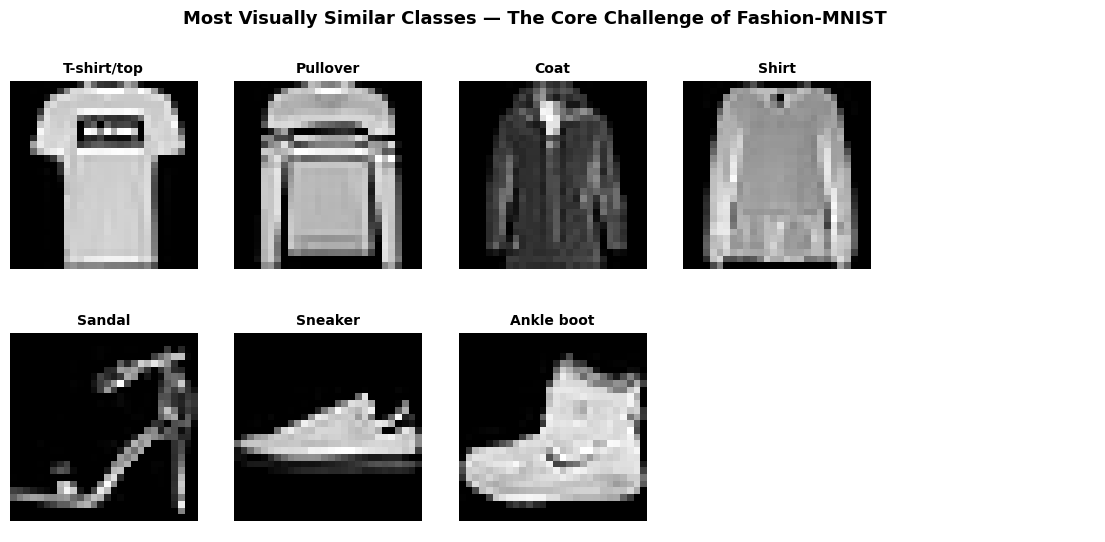

 Saved: figures/confusable_classes1.png


In [8]:
# EDA Figure 5: Visually similar classes

confusable = {
    "Upper body": [0, 2, 4, 6],   # T-shirt, Pullover, Coat, Shirt
    "Footwear":   [5, 7, 9],       # Sandal, Sneaker, Ankle boot
}

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Most Visually Similar Classes — The Core Challenge of Fashion-MNIST",
             fontsize=13, fontweight='bold')

# Show 5 examples of the 4 upper body confusable classes
upper_indices = [0, 2, 4, 6]  # T-shirt, Pullover, Coat, Shirt
foot_indices  = [5, 7, 9]     # Sandal, Sneaker, Ankle boot

for col, class_idx in enumerate(upper_indices):
    idx = next(i for i, (_, l) in enumerate(eda_dataset) if l == class_idx)
    img = eda_dataset[idx][0].squeeze().numpy()
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(CLASS_NAMES[class_idx], fontweight='bold', fontsize=10)
    axes[0, col].axis('off')
axes[0, 4].axis('off')  # empty slot

for col, class_idx in enumerate(foot_indices):
    idx = next(i for i, (_, l) in enumerate(eda_dataset) if l == class_idx)
    img = eda_dataset[idx][0].squeeze().numpy()
    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].set_title(CLASS_NAMES[class_idx], fontweight='bold', fontsize=10)
    axes[1, col].axis('off')
axes[1, 3].axis('off')  # empty slots
axes[1, 4].axis('off')

#plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.savefig('figures/confusable_classes1.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: figures/confusable_classes1.png")

## Why MLP and CNN? — Model Selection Rationale

### MLP Baseline

A Multi-Layer Perceptron (MLP) provides a simple baseline for evaluating
Fashion-MNIST classification performance.

Because the input image is flattened into a one-dimensional vector, the MLP
does not explicitly preserve the spatial relationships between neighboring
pixels. However, it provides a useful reference point for evaluating the
benefit of convolutional architectures.

### Convolutional Neural Network

CNNs are well suited to image classification because convolutional filters
can learn local spatial patterns such as edges, textures, and shapes.

For Fashion-MNIST, a compact CNN provides a good balance between model
capacity and computational complexity.

### Additional Experiments

To investigate the effect of different modeling choices, two additional
experiments are included:

- CNN with data augmentation — evaluates whether transformations improve
  generalization.
- Deeper CNN — evaluates whether additional convolutional depth improves
  classification performance.

The models are compared using validation performance during development
and test accuracy, Macro-F1 score, parameter count, and per-class
performance during final evaluation.

### **Part 2 : MLP Baseline**

In [9]:
# Training Function (reusable for CNN too!)

def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=15):
    
    train_losses, val_losses     = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc  = 100. * correct / total

        # VALIDATION PHASE
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)

                val_loss    += loss.item()
                _, predicted = outputs.max(1)
                val_total   += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc  = 100. * val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1:2d}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [10]:
# MLP Model Definition

import torch.nn as nn
import torch.optim as optim

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),                   # 28×28 → 784
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)              # 10 classes output
        )

    def forward(self, x):
        return self.network(x)

# Initialize model, loss, optimizer
mlp_model = MLP().to(device)
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(mlp_model.parameters(), lr=0.001)

# Print architecture summary
print("=== MLP ARCHITECTURE ===")
print(mlp_model)
total_params = sum(p.numel() for p in mlp_model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

=== MLP ARCHITECTURE ===
MLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 567,434


In [11]:
# Train the MLP

print("TRAINING MLP\n")
mlp_train_losses, mlp_val_losses, \
mlp_train_accs,   mlp_val_accs = train_model(
    mlp_model, train_loader, val_loader,
    optimizer, criterion, epochs=15
)

print(f"\n MLP Training complete!")
print(f"   Best Validation Accuracy: {max(mlp_val_accs):.2f}%")

TRAINING MLP

Epoch [ 1/15] Train Loss: 0.5636 | Train Acc: 79.36% | Val Loss: 0.4361 | Val Acc: 84.43%
Epoch [ 2/15] Train Loss: 0.4310 | Train Acc: 84.46% | Val Loss: 0.3744 | Val Acc: 86.35%
Epoch [ 3/15] Train Loss: 0.3941 | Train Acc: 85.67% | Val Loss: 0.3702 | Val Acc: 86.48%
Epoch [ 4/15] Train Loss: 0.3752 | Train Acc: 86.33% | Val Loss: 0.3548 | Val Acc: 87.42%
Epoch [ 5/15] Train Loss: 0.3566 | Train Acc: 86.93% | Val Loss: 0.3733 | Val Acc: 86.72%
Epoch [ 6/15] Train Loss: 0.3439 | Train Acc: 87.25% | Val Loss: 0.3505 | Val Acc: 87.20%
Epoch [ 7/15] Train Loss: 0.3296 | Train Acc: 88.01% | Val Loss: 0.3420 | Val Acc: 87.90%
Epoch [ 8/15] Train Loss: 0.3272 | Train Acc: 87.92% | Val Loss: 0.3346 | Val Acc: 88.05%
Epoch [ 9/15] Train Loss: 0.3157 | Train Acc: 88.37% | Val Loss: 0.3399 | Val Acc: 87.62%
Epoch [10/15] Train Loss: 0.3072 | Train Acc: 88.66% | Val Loss: 0.3305 | Val Acc: 87.68%
Epoch [11/15] Train Loss: 0.2994 | Train Acc: 88.90% | Val Loss: 0.3408 | Val Acc: 87.

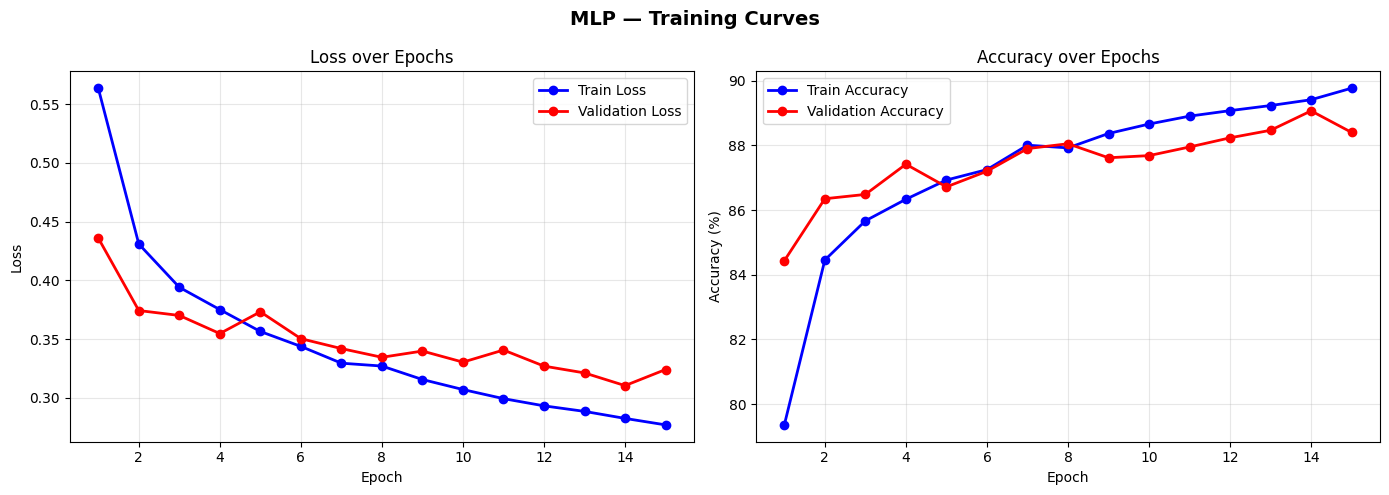

 Saved: figures/mlp_training_curves.png


In [12]:
# MLP Training Curves

epochs_range = range(1, 16)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLP — Training Curves', fontsize=14, fontweight='bold')

# Loss
ax1.plot(epochs_range, mlp_train_losses, 'b-o', label='Train Loss',      linewidth=2)
ax1.plot(epochs_range, mlp_val_losses,   'r-o', label='Validation Loss', linewidth=2)
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, mlp_train_accs, 'b-o', label='Train Accuracy',      linewidth=2)
ax2.plot(epochs_range, mlp_val_accs,   'r-o', label='Validation Accuracy', linewidth=2)
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: figures/mlp_training_curves.png")

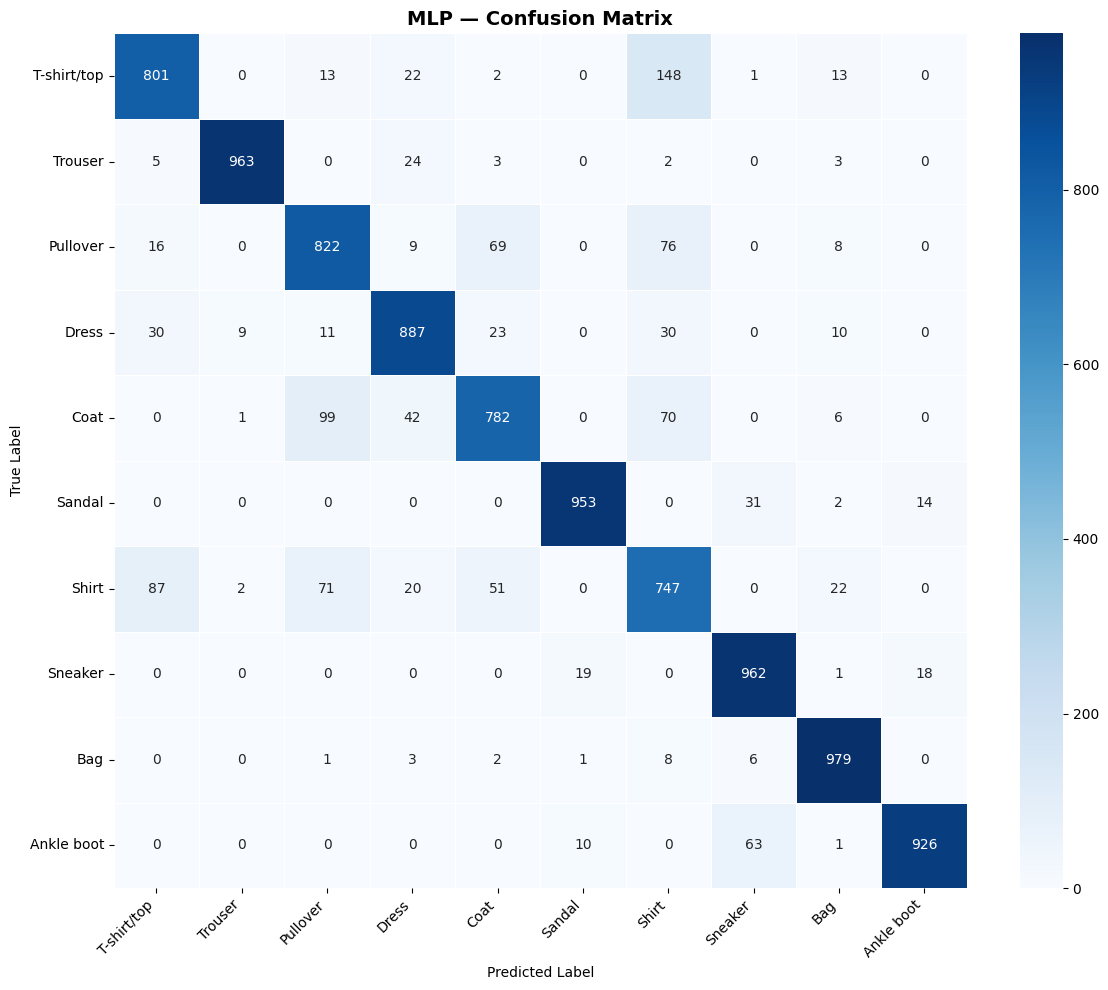


MLP CLASSIFICATION REPORT
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.80      0.83      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.81      0.82      0.82      1000
       Dress       0.88      0.89      0.88      1000
        Coat       0.84      0.78      0.81      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.69      0.75      0.72      1000
     Sneaker       0.90      0.96      0.93      1000
         Bag       0.94      0.98      0.96      1000
  Ankle boot       0.97      0.93      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [13]:
# MLP Confusion Matrix + Per-class Metrics

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

mlp_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = mlp_model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.5)
ax.set_title('MLP — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/confusion_matrix_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class report
print("\nMLP CLASSIFICATION REPORT")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

### **Part 3 : CNN**

In [14]:
# CNN Model Definition
import torch.nn as nn
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # --- CONVOLUTIONAL BLOCKS ---
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 28×28×1  → 28×28×32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), # 28×28×32 → 28×28×32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 28×28×32 → 14×14×32
            nn.Dropout2d(0.25)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 14×14×32 → 14×14×64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # 14×14×64 → 14×14×64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 14×14×64 → 7×7×64
            nn.Dropout2d(0.25)
        )
        
        # --- CLASSIFIER HEAD ---
        self.classifier = nn.Sequential(
            nn.Flatten(),               # 7×7×64 = 3136
            nn.Linear(3136, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, 10)          # 10 classes
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

# Initialize
cnn_model  = CNN().to(device)
criterion  = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

# Scheduler: reduce LR when val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cnn, mode='min', factor=0.5, patience=3)

print("CNN ARCHITECTURE")
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

CNN ARCHITECTURE
CNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil

In [15]:
# Train CNN (with scheduler)

def train_model_with_scheduler(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs=20):
    train_losses, val_losses         = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        # TRAINING
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc  = 100. * correct / total

        # VALIDATION
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs     = model(images)
                loss        = criterion(outputs, labels)
                val_loss   += loss.item()
                _, predicted = outputs.max(1)
                val_total  += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc  = 100. * val_correct / val_total

        # Step scheduler on val loss
        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1:2d}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies

print("TRAINING CNN\n")
cnn_train_losses, cnn_val_losses, \
cnn_train_accs,   cnn_val_accs = train_model_with_scheduler(
    cnn_model, train_loader, val_loader,
    optimizer_cnn, criterion, scheduler, epochs=20
)

print(f"\n CNN Training complete!")
print(f"   Best Validation Accuracy: {max(cnn_val_accs):.2f}%")

TRAINING CNN

Epoch [ 1/20] Train Loss: 0.4460 | Train Acc: 83.89% | Val Loss: 0.2841 | Val Acc: 89.55%
Epoch [ 2/20] Train Loss: 0.3109 | Train Acc: 88.79% | Val Loss: 0.2504 | Val Acc: 90.73%
Epoch [ 3/20] Train Loss: 0.2783 | Train Acc: 90.03% | Val Loss: 0.2279 | Val Acc: 91.32%
Epoch [ 4/20] Train Loss: 0.2539 | Train Acc: 90.95% | Val Loss: 0.2327 | Val Acc: 91.75%
Epoch [ 5/20] Train Loss: 0.2391 | Train Acc: 91.51% | Val Loss: 0.2083 | Val Acc: 92.12%
Epoch [ 6/20] Train Loss: 0.2242 | Train Acc: 91.87% | Val Loss: 0.2047 | Val Acc: 92.37%
Epoch [ 7/20] Train Loss: 0.2138 | Train Acc: 92.19% | Val Loss: 0.2028 | Val Acc: 92.35%
Epoch [ 8/20] Train Loss: 0.1993 | Train Acc: 92.64% | Val Loss: 0.1911 | Val Acc: 92.88%
Epoch [ 9/20] Train Loss: 0.1906 | Train Acc: 93.13% | Val Loss: 0.1883 | Val Acc: 92.97%
Epoch [10/20] Train Loss: 0.1801 | Train Acc: 93.50% | Val Loss: 0.1807 | Val Acc: 93.75%
Epoch [11/20] Train Loss: 0.1728 | Train Acc: 93.79% | Val Loss: 0.1969 | Val Acc: 92.

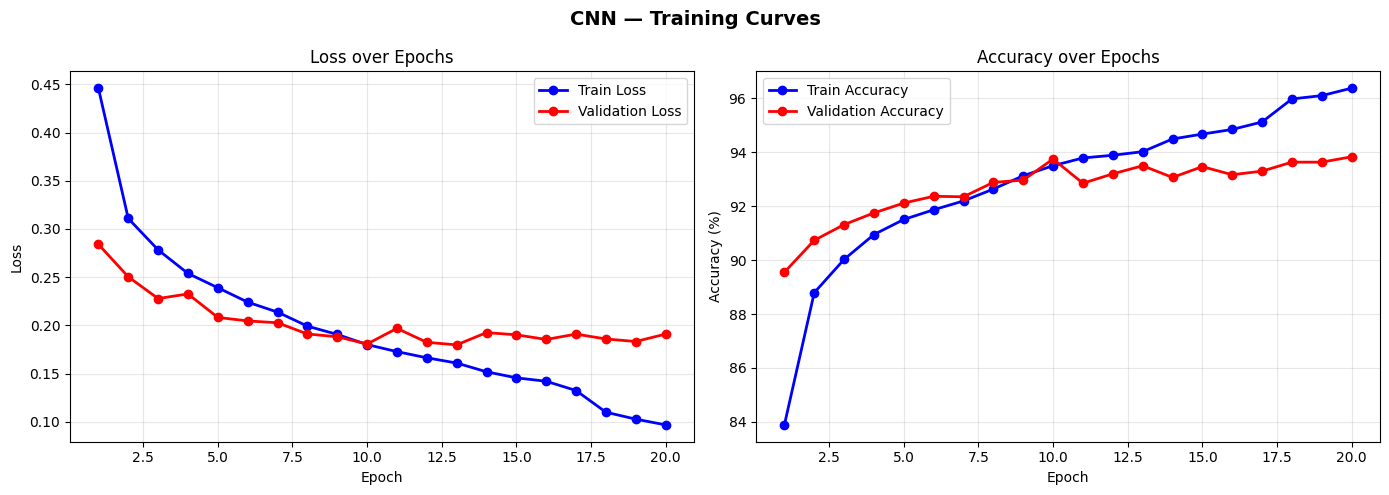

 Saved: figures/cnn_training_curves.png


In [16]:
# CNN Training Curves

epochs_range = range(1, 21)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN — Training Curves', fontsize=14, fontweight='bold')

ax1.plot(epochs_range, cnn_train_losses, 'b-o', label='Train Loss',      linewidth=2)
ax1.plot(epochs_range, cnn_val_losses,   'r-o', label='Validation Loss', linewidth=2)
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, cnn_train_accs, 'b-o', label='Train Accuracy',      linewidth=2)
ax2.plot(epochs_range, cnn_val_accs,   'r-o', label='Validation Accuracy', linewidth=2)
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: figures/cnn_training_curves.png")

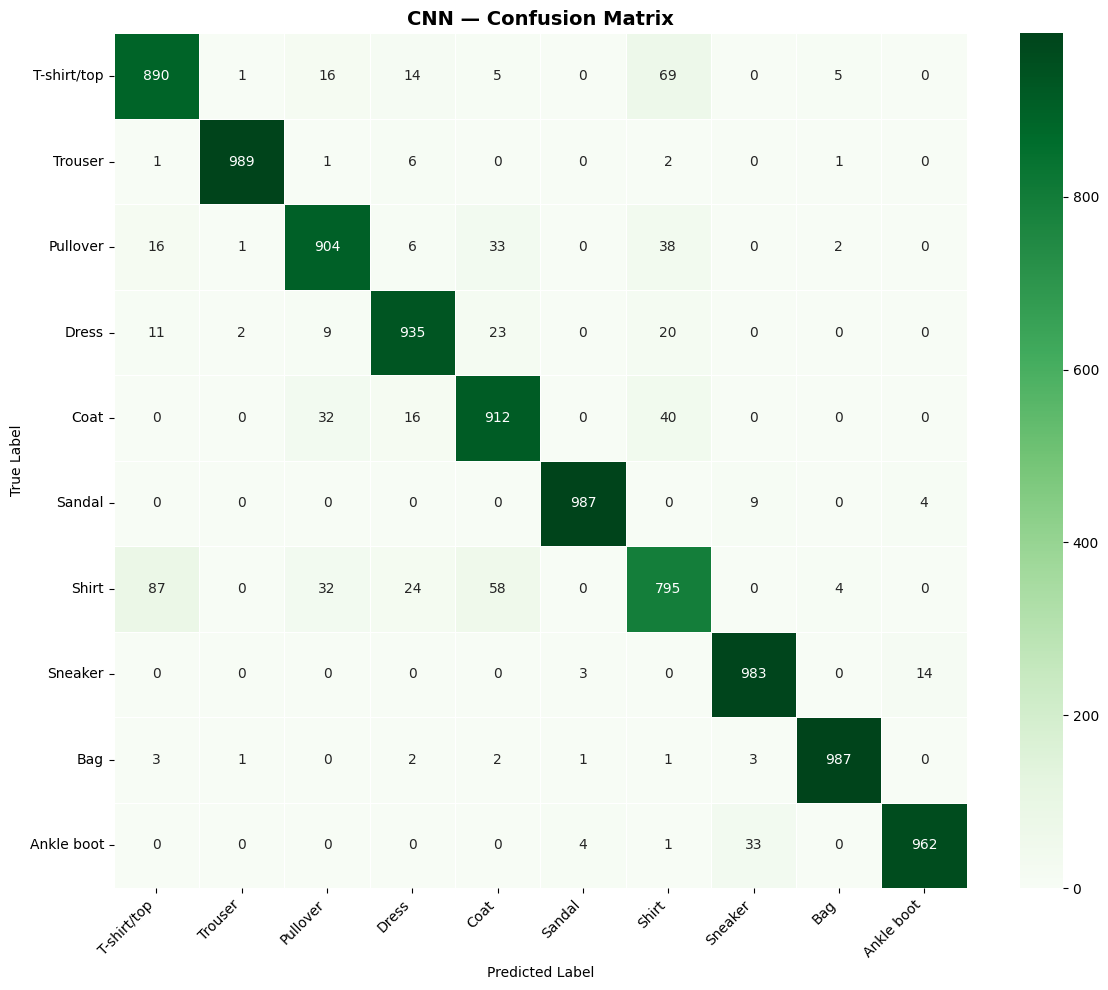


=== CNN CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.89      0.89      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.91      0.90      0.91      1000
       Dress       0.93      0.94      0.93      1000
        Coat       0.88      0.91      0.90      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.82      0.80      0.81      1000
     Sneaker       0.96      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [17]:
# CNN Confusion Matrix + Report

cnn_model.eval()
all_preds_cnn, all_labels_cnn = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_model(images)
        _, predicted = outputs.max(1)
        all_preds_cnn.extend(predicted.cpu().numpy())
        all_labels_cnn.extend(labels.numpy())

cm_cnn = confusion_matrix(all_labels_cnn, all_preds_cnn)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.5)
ax.set_title('CNN — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/confusion_matrix_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== CNN CLASSIFICATION REPORT ===")
print(classification_report(all_labels_cnn, all_preds_cnn, target_names=CLASS_NAMES))

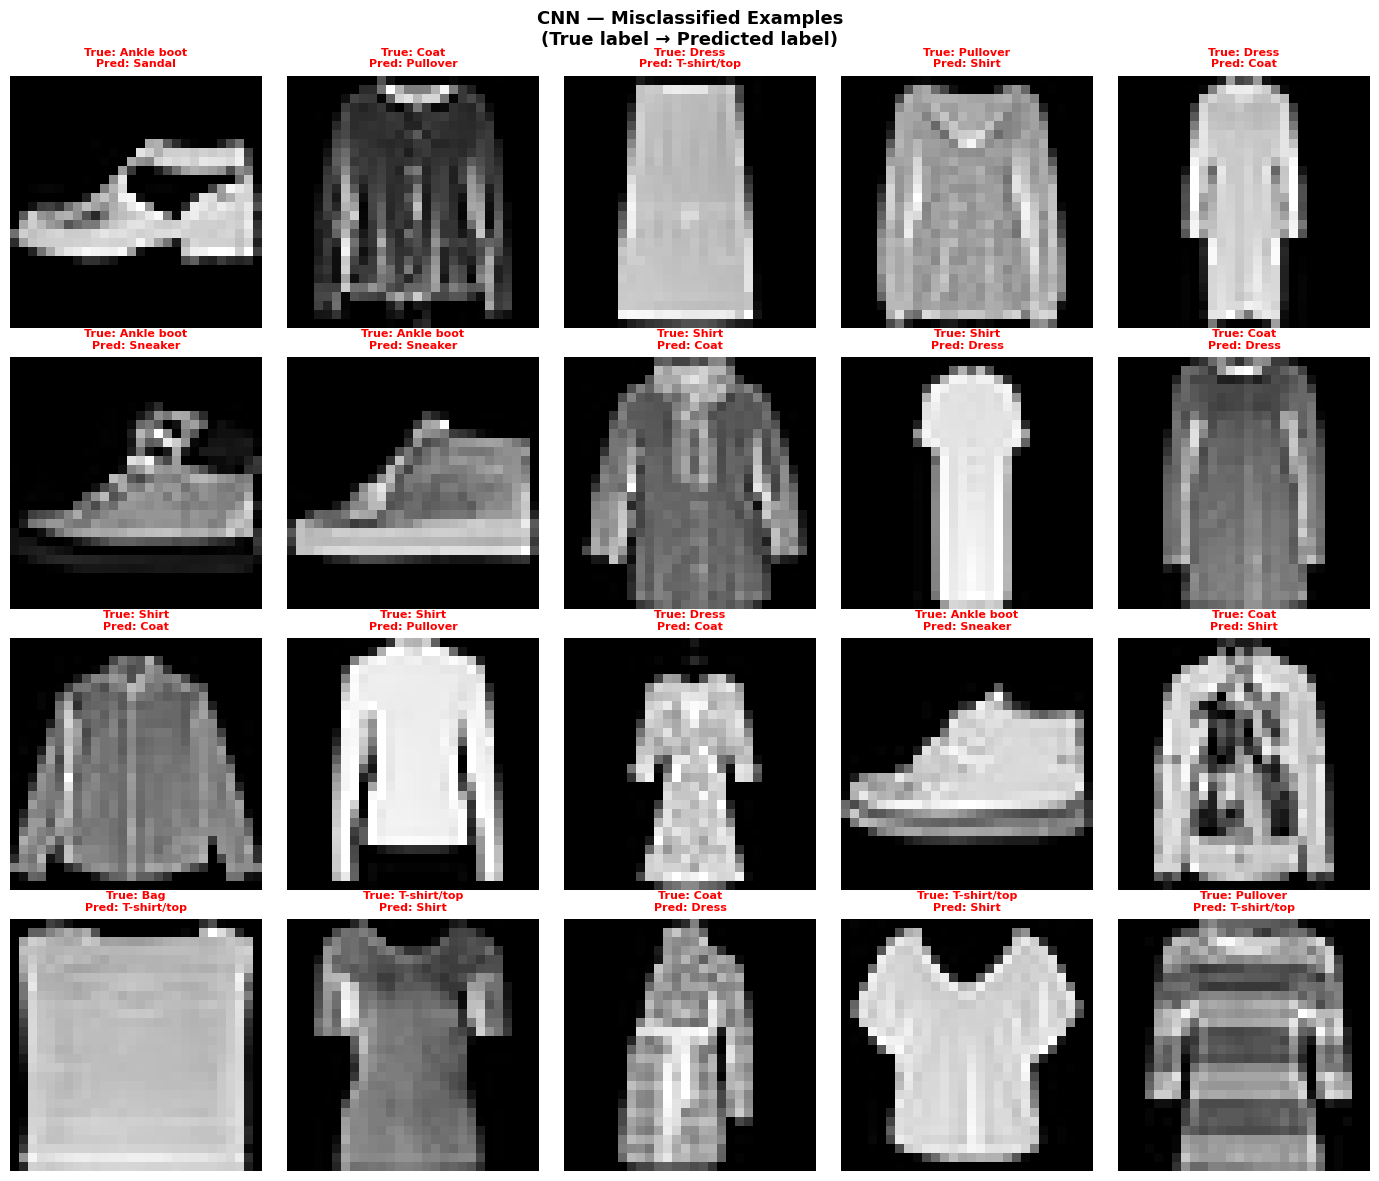

 Saved: figures/misclassified_examples.png


In [18]:
# Misclassified Examples (CNN)

cnn_model.eval()
misclassified_imgs, misclassified_true, misclassified_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_model(images)
        _, predicted = outputs.max(1)
        
        mask = predicted.cpu() != labels
        misclassified_imgs.extend(images.cpu()[mask])
        misclassified_true.extend(labels[mask])
        misclassified_pred.extend(predicted.cpu()[mask])
        
        if len(misclassified_imgs) >= 20:
            break

# Show 20 misclassified examples
fig, axes = plt.subplots(4, 5, figsize=(14, 12))
fig.suptitle('CNN — Misclassified Examples\n(True label → Predicted label)', 
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img  = misclassified_imgs[i].squeeze().numpy()
    true = CLASS_NAMES[misclassified_true[i]]
    pred = CLASS_NAMES[misclassified_pred[i]]
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {true}\nPred: {pred}', 
                 fontsize=8, color='red', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('figures/misclassified_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: figures/misclassified_examples.png")

### **Part 4 : CNN + Data Augmentation**

In [19]:
# Augmented Training Data

from torch.utils.data import Subset

# Data augmentation applied ONLY to the training set
train_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Reload the original Fashion-MNIST training set, this time with augmentation enabled
full_train_dataset_aug = torchvision.datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=train_transform_aug
)

# Use exactly the SAME indices as the original 54,000-image training subset created earlier
train_dataset_aug = Subset(
    full_train_dataset_aug,
    train_dataset.indices
)

# Augmented training loader
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

print("AUGMENTED TRAINING SET")
print(f"Training samples: {len(train_dataset_aug):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")

AUGMENTED TRAINING SET
Training samples: 54,000
Validation samples: 6,000
Test samples: 10,000


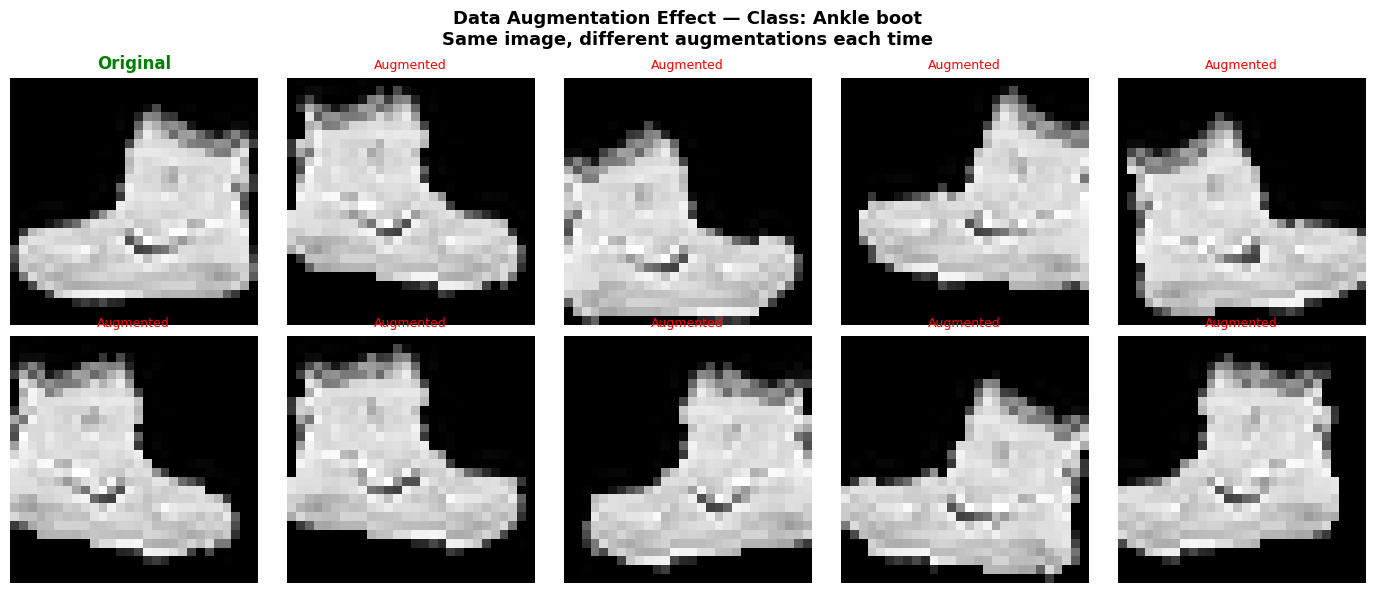

Saved: figures/augmentation_effect.png


In [20]:
# Show Augmentation Effect

original_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Get one sample image
sample_idx = 0

raw_dataset = torchvision.datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=None
)

raw_img, sample_label = raw_dataset[sample_idx]

original_img = torchvision.datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=original_transform
)[sample_idx][0]

# Apply augmentation several times to the same image
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

fig.suptitle(
    f'Data Augmentation Effect — Class: {CLASS_NAMES[sample_label]}\n'
    f'Same image, different augmentations each time',
    fontsize=13,
    fontweight='bold'
)

# Original image
axes[0, 0].imshow(original_img.squeeze().numpy(), cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold', color='green')
axes[0, 0].axis('off')

# Augmentation transformations
aug_only = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
])

# 9 augmented versions
positions = [
    (0,1), (0,2), (0,3), (0,4),
    (1,0), (1,1), (1,2), (1,3), (1,4)
]

for pos in positions:
    aug_img = aug_only(raw_img)
    axes[pos].imshow(aug_img, cmap='gray')
    axes[pos].set_title('Augmented', fontsize=9, color='red')
    axes[pos].axis('off')

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'augmentation_effect.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Saved: figures/augmentation_effect.png")

In [21]:
# Train CNN + Augmentation
# (Same architecture as CNN — fair comparison!)

cnn_aug_model = CNN().to(device)  # exact same architecture
optimizer_aug = optim.Adam(cnn_aug_model.parameters(), lr=0.001)
scheduler_aug = optim.lr_scheduler.ReduceLROnPlateau(optimizer_aug, mode='min', factor=0.5, patience=3)

print("TRAINING CNN + DATA AUGMENTATION")
print("Architecture: identical to CNN (fair comparison)")
print("Difference  : training data is augmented\n")

cnn_aug_train_losses, cnn_aug_val_losses, \
cnn_aug_train_accs,   cnn_aug_val_accs = train_model_with_scheduler(
    cnn_aug_model, train_loader_aug, val_loader,
    optimizer_aug, criterion, scheduler_aug, epochs=20
)

print(f"\n CNN + Augmentation Training complete!")
print(f"   Best Validation Accuracy : {max(cnn_aug_val_accs):.2f}%")
print(f"   CNN (no aug) best was    : {max(cnn_val_accs):.2f}%")
print(f"   Difference               : {max(cnn_aug_val_accs) - max(cnn_val_accs):+.2f}%")

TRAINING CNN + DATA AUGMENTATION
Architecture: identical to CNN (fair comparison)
Difference  : training data is augmented

Epoch [ 1/20] Train Loss: 0.6838 | Train Acc: 74.82% | Val Loss: 0.4215 | Val Acc: 84.48%
Epoch [ 2/20] Train Loss: 0.5248 | Train Acc: 80.61% | Val Loss: 0.3569 | Val Acc: 87.00%
Epoch [ 3/20] Train Loss: 0.4678 | Train Acc: 82.75% | Val Loss: 0.3370 | Val Acc: 87.65%
Epoch [ 4/20] Train Loss: 0.4316 | Train Acc: 84.15% | Val Loss: 0.3078 | Val Acc: 88.43%
Epoch [ 5/20] Train Loss: 0.4090 | Train Acc: 85.05% | Val Loss: 0.2898 | Val Acc: 89.57%
Epoch [ 6/20] Train Loss: 0.4003 | Train Acc: 85.39% | Val Loss: 0.2927 | Val Acc: 89.68%
Epoch [ 7/20] Train Loss: 0.3769 | Train Acc: 86.28% | Val Loss: 0.2982 | Val Acc: 90.12%
Epoch [ 8/20] Train Loss: 0.3656 | Train Acc: 86.65% | Val Loss: 0.2658 | Val Acc: 90.33%
Epoch [ 9/20] Train Loss: 0.3558 | Train Acc: 87.14% | Val Loss: 0.2655 | Val Acc: 91.15%
Epoch [10/20] Train Loss: 0.3548 | Train Acc: 87.08% | Val Loss: 0

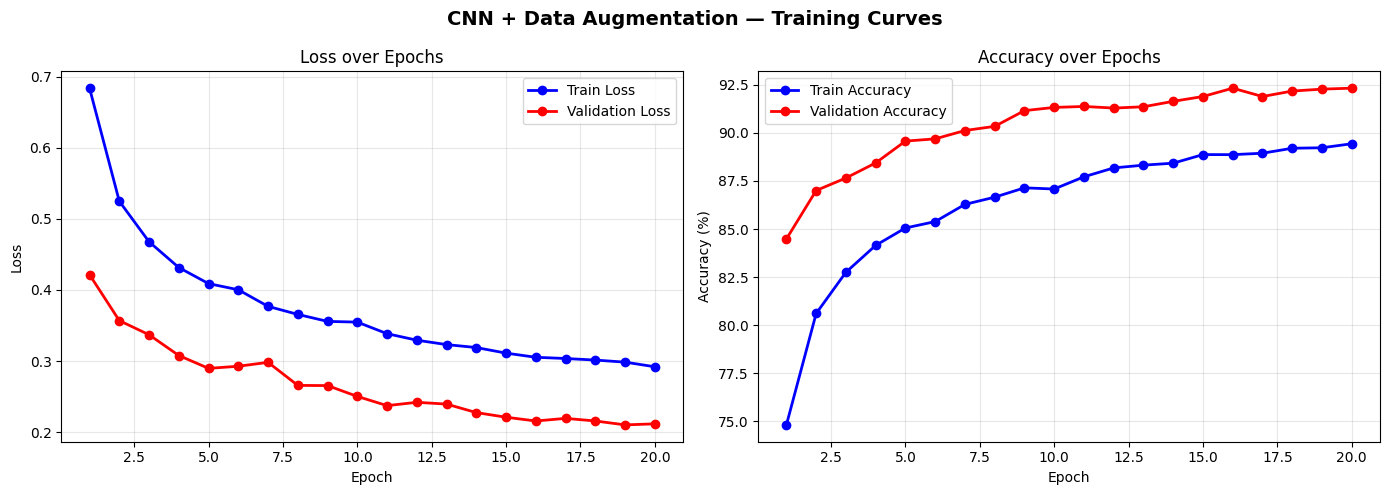

Saved: figures/cnn_aug_training_curves.png


In [22]:
# Train CNN + Aug Training Curves

epochs_range = range(1, 21)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN + Data Augmentation — Training Curves',
             fontsize=14, fontweight='bold')

ax1.plot(epochs_range, cnn_aug_train_losses,
         'b-o', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, cnn_aug_val_losses,
         'r-o', label='Validation Loss', linewidth=2)
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, cnn_aug_train_accs,
         'b-o', label='Train Accuracy', linewidth=2)
ax2.plot(epochs_range, cnn_aug_val_accs,
         'r-o', label='Validation Accuracy', linewidth=2)
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/cnn_aug_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/cnn_aug_training_curves.png")

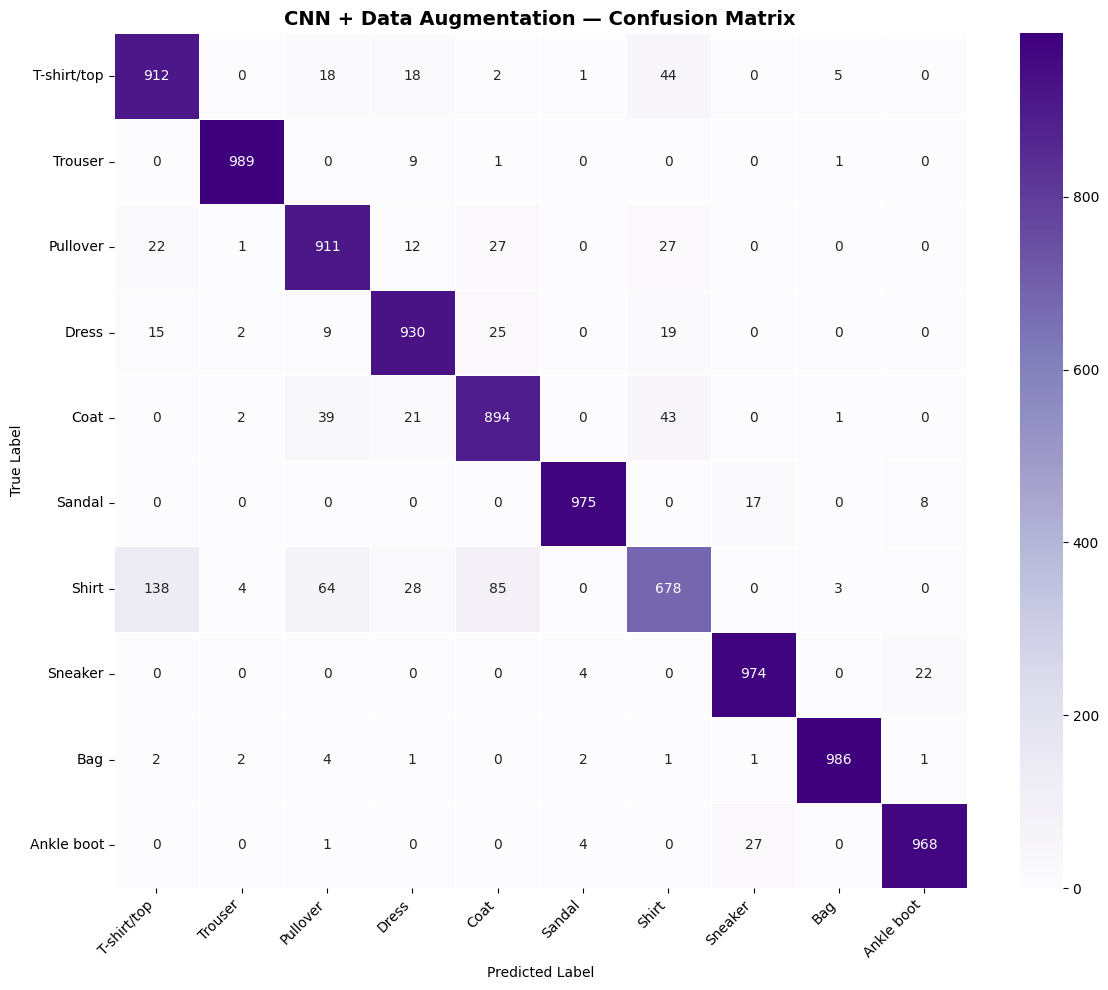


 CNN + AUGMENTATION CLASSIFICATION REPORT 
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.91      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.87      0.91      0.89      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.86      0.89      0.88      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.83      0.68      0.75      1000
     Sneaker       0.96      0.97      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [23]:
# CNN + Aug Confusion Matrix

cnn_aug_model.eval()
all_preds_aug, all_labels_aug = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_aug_model(images)
        _, predicted = outputs.max(1)
        all_preds_aug.extend(predicted.cpu().numpy())
        all_labels_aug.extend(labels.numpy())

cm_aug = confusion_matrix(all_labels_aug, all_preds_aug)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_aug, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.5)
ax.set_title('CNN + Data Augmentation — Confusion Matrix',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/confusion_matrix_cnn_aug.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n CNN + AUGMENTATION CLASSIFICATION REPORT ")
print(classification_report(
    all_labels_aug, all_preds_aug, target_names=CLASS_NAMES))

### **Part 5 : Deeper CNN (3 Conv Blocks)**

In [24]:
# Deeper CNN (3 Convolutional Blocks)

class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()

        # BLOCK 1: 28×28×1 → 14×14×32
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # BLOCK 2: 14×14×32 → 7×7×64
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # BLOCK 3 (NEW): 7×7×64 → 3×3×128
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # CLASSIFIER: 3×3×128=1152 → 10
        self.classifier = nn.Sequential(
            nn.Flatten(),               # 3×3×128 = 1,152
            nn.Linear(1152, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x

# Initialize
deep_cnn_model  = DeepCNN().to(device)
optimizer_deep  = optim.Adam(deep_cnn_model.parameters(), lr=0.001)
scheduler_deep  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_deep, mode='min', factor=0.5, patience=3)

print("DEEP CNN ARCHITECTURE")
print(deep_cnn_model)

# Exact trainable parameter counts
mlp_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
cnn_aug_params = sum(p.numel() for p in cnn_aug_model.parameters() if p.requires_grad)
deep_params = sum(p.numel() for p in deep_cnn_model.parameters() if p.requires_grad)

print(f"\nTotal trainable parameters: {deep_params:,}")

print("\nARCHITECTURE COMPARISON")
print(f"{'Model':<20} {'Conv Blocks':>12} {'Feature Map':>14} {'Params':>12}")
print("-" * 60)
print(f"{'MLP':<20} {'0':>12} {'784 (flat)':>14} {mlp_params:>12,}")
print(f"{'CNN':<20} {'2':>12} {'7×7×64':>14} {cnn_params:>12,}")
print(f"{'CNN+Aug':<20} {'2':>12} {'7×7×64':>14} {cnn_aug_params:>12,}")
print(f"{'Deep CNN':<20} {'3':>12} {'3×3×128':>14} {deep_params:>12,}")

DEEP CNN ARCHITECTURE
DeepCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

In [25]:
# Train Deep CNN

print("TRAINING DEEP CNN (3 BLOCKS)")
print("Hypothesis: Does additional depth improve validation performance?\n")

deep_train_losses, deep_val_losses, \
deep_train_accs,   deep_val_accs = train_model_with_scheduler(
    deep_cnn_model, train_loader, val_loader,
    optimizer_deep, criterion, scheduler_deep, epochs=20
)

print(f"\n Deep CNN Training complete!")
print("\nVALIDATION PERFORMANCE COMPARISON")
print(f"MLP      best val acc : {max(mlp_val_accs):.2f}%")
print(f"CNN      best val acc : {max(cnn_val_accs):.2f}%")
print(f"CNN+Aug  best val acc : {max(cnn_aug_val_accs):.2f}%")
print(f"Deep CNN best val acc : {max(deep_val_accs):.2f}%")

TRAINING DEEP CNN (3 BLOCKS)
Hypothesis: Does additional depth improve validation performance?

Epoch [ 1/20] Train Loss: 0.5070 | Train Acc: 81.38% | Val Loss: 0.2952 | Val Acc: 88.95%
Epoch [ 2/20] Train Loss: 0.3240 | Train Acc: 88.33% | Val Loss: 0.2537 | Val Acc: 90.43%
Epoch [ 3/20] Train Loss: 0.2846 | Train Acc: 89.74% | Val Loss: 0.2538 | Val Acc: 90.93%
Epoch [ 4/20] Train Loss: 0.2645 | Train Acc: 90.36% | Val Loss: 0.2327 | Val Acc: 91.30%
Epoch [ 5/20] Train Loss: 0.2494 | Train Acc: 91.00% | Val Loss: 0.2242 | Val Acc: 91.68%
Epoch [ 6/20] Train Loss: 0.2344 | Train Acc: 91.61% | Val Loss: 0.2022 | Val Acc: 92.68%
Epoch [ 7/20] Train Loss: 0.2234 | Train Acc: 91.95% | Val Loss: 0.2014 | Val Acc: 92.42%
Epoch [ 8/20] Train Loss: 0.2087 | Train Acc: 92.63% | Val Loss: 0.1950 | Val Acc: 93.13%
Epoch [ 9/20] Train Loss: 0.2024 | Train Acc: 92.75% | Val Loss: 0.1839 | Val Acc: 93.57%
Epoch [10/20] Train Loss: 0.1930 | Train Acc: 93.03% | Val Loss: 0.1856 | Val Acc: 93.23%
Epoc

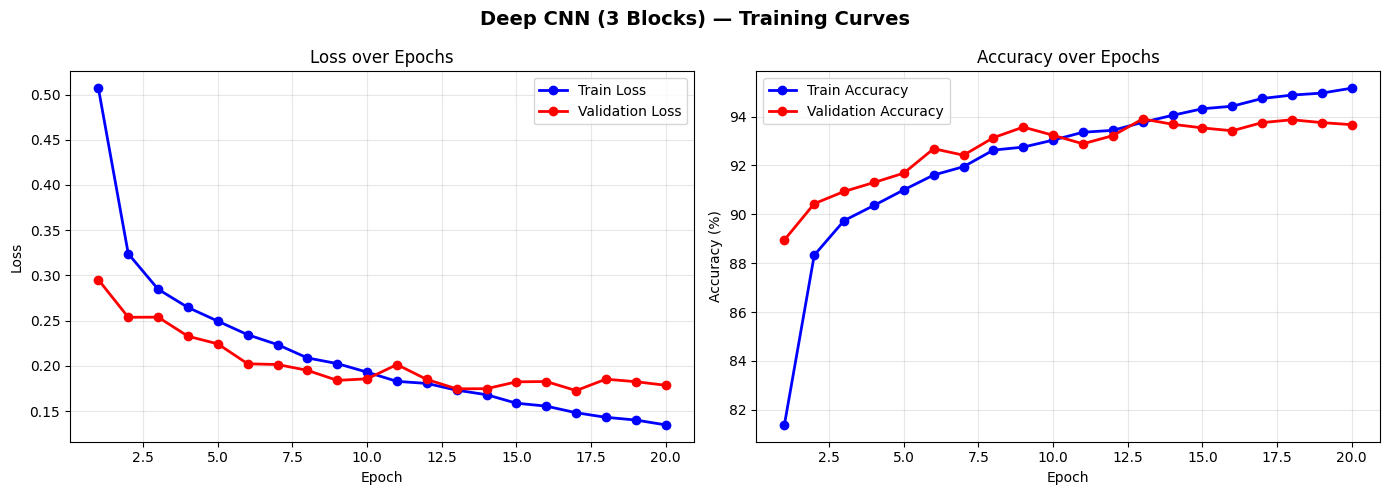

Saved: figures/deep_cnn_training_curves.png


In [26]:
# Deep CNN Training Curves

epochs_range = range(1, 21)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Deep CNN (3 Blocks) — Training Curves',
             fontsize=14, fontweight='bold')

ax1.plot(epochs_range, deep_train_losses,
         'b-o', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, deep_val_losses,
         'r-o', label='Validation Loss', linewidth=2)
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, deep_train_accs,
         'b-o', label='Train Accuracy', linewidth=2)
ax2.plot(epochs_range, deep_val_accs,
         'r-o', label='Validation Accuracy', linewidth=2)
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/deep_cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/deep_cnn_training_curves.png")

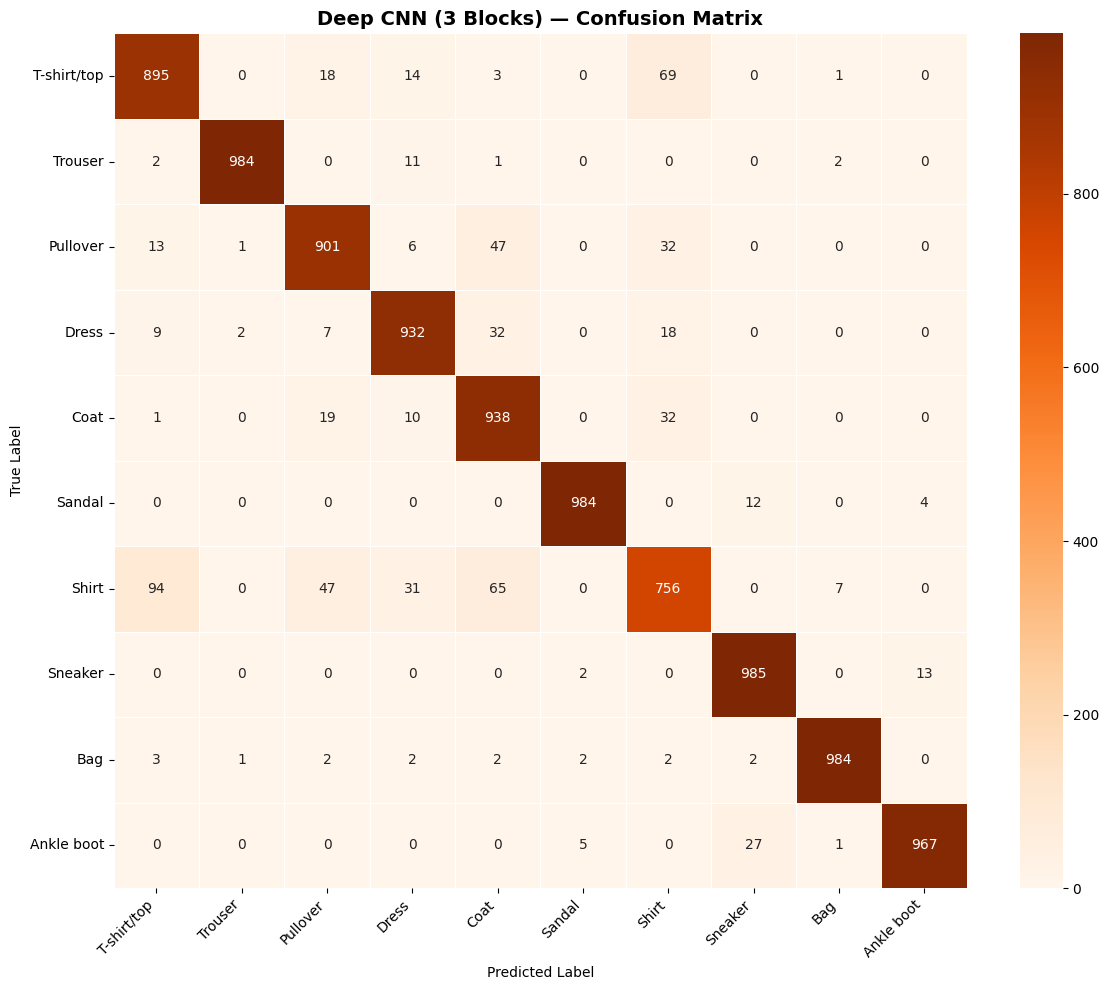


 DEEP CNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.90      0.89      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.91      0.90      0.90      1000
       Dress       0.93      0.93      0.93      1000
        Coat       0.86      0.94      0.90      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.83      0.76      0.79      1000
     Sneaker       0.96      0.98      0.97      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.98      0.97      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [27]:
# Deep CNN Confusion Matrix + Report

deep_cnn_model.eval()
all_preds_deep, all_labels_deep = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = deep_cnn_model(images)
        _, predicted = outputs.max(1)
        all_preds_deep.extend(predicted.cpu().numpy())
        all_labels_deep.extend(labels.numpy())

cm_deep = confusion_matrix(all_labels_deep, all_preds_deep)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.5)
ax.set_title('Deep CNN (3 Blocks) — Confusion Matrix',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/confusion_matrix_deep_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n DEEP CNN CLASSIFICATION REPORT")
print(classification_report(
    all_labels_deep, all_preds_deep, target_names=CLASS_NAMES))

### **Part 6 - Final benchmarking**

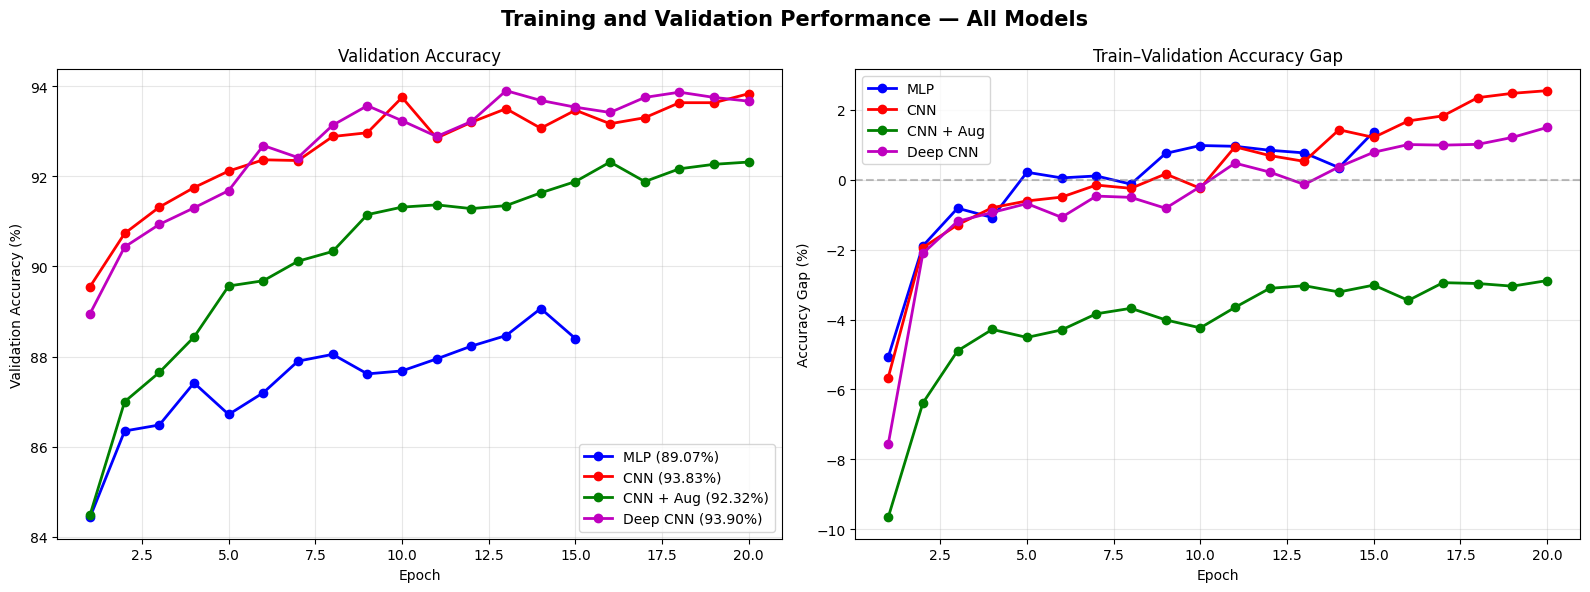

TEST-SET MODEL BENCHMARKING
Model                 Test Acc    Macro F1     Parameters    Blocks   Final Gap
----------------------------------------------------------------------------------
MLP                     88.22%      0.8825        567,434         0      +1.37%
CNN                     93.44%      0.9343      1,677,674         2      +2.54%
CNN + Aug               92.17%      0.9204      1,677,674         2      -2.89%
Deep CNN                93.26%      0.9322      1,012,586         3      +1.49%

PER-CLASS TEST F1 SCORES
Class                 MLP       CNN     CNN+Aug    Deep CNN
-----------------------------------------------------------
T-shirt/top         0.826     0.886       0.873       0.887
Trouser             0.975     0.992       0.989       0.990
Pullover            0.815     0.907       0.891       0.904
Dress               0.884     0.934       0.921       0.929
Coat                0.810     0.897       0.879       0.898
Sandal              0.961     0.989       0

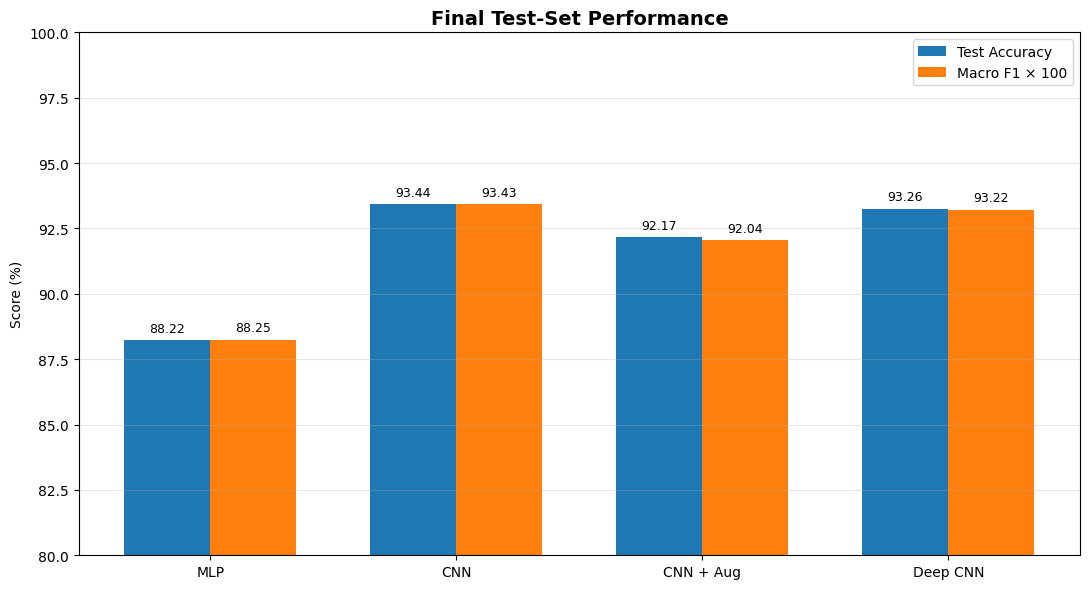


Saved: figures/benchmarking_barchart.png


In [28]:
# COMPLETE MODEL BENCHMARKING

from sklearn.metrics import classification_report

# TEST-SET CLASSIFICATION REPORTS
mlp_report = classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)

cnn_report = classification_report(
    all_labels_cnn, all_preds_cnn,
    target_names=CLASS_NAMES,
    output_dict=True
)

aug_report = classification_report(
    all_labels_aug, all_preds_aug,
    target_names=CLASS_NAMES,
    output_dict=True
)

deep_report = classification_report(
    all_labels_deep, all_preds_deep,
    target_names=CLASS_NAMES,
    output_dict=True
)

# TRAINING–VALIDATION GENERALIZATION GAPS
mlp_gap = [
    train - val
    for train, val in zip(mlp_train_accs, mlp_val_accs)
]

cnn_gap = [
    train - val
    for train, val in zip(cnn_train_accs, cnn_val_accs)
]

cnn_aug_gap = [
    train - val
    for train, val in zip(cnn_aug_train_accs, cnn_aug_val_accs)
]

deep_gap = [
    train - val
    for train, val in zip(deep_train_accs, deep_val_accs)
]

# VALIDATION PERFORMANCE DURING TRAINING
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle(
    "Training and Validation Performance — All Models",
    fontsize=15,
    fontweight="bold"
)

# Validation accuracy
axes[0].plot(
    range(1, len(mlp_val_accs) + 1),
    mlp_val_accs,
    "b-o",
    label=f"MLP ({max(mlp_val_accs):.2f}%)",
    linewidth=2
)

axes[0].plot(
    range(1, len(cnn_val_accs) + 1),
    cnn_val_accs,
    "r-o",
    label=f"CNN ({max(cnn_val_accs):.2f}%)",
    linewidth=2
)

axes[0].plot(
    range(1, len(cnn_aug_val_accs) + 1),
    cnn_aug_val_accs,
    "g-o",
    label=f"CNN + Aug ({max(cnn_aug_val_accs):.2f}%)",
    linewidth=2
)

axes[0].plot(
    range(1, len(deep_val_accs) + 1),
    deep_val_accs,
    "m-o",
    label=f"Deep CNN ({max(deep_val_accs):.2f}%)",
    linewidth=2
)

axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Accuracy (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Generalization gap
axes[1].plot(
    range(1, len(mlp_gap) + 1),
    mlp_gap,
    "b-o",
    label="MLP",
    linewidth=2
)

axes[1].plot(
    range(1, len(cnn_gap) + 1),
    cnn_gap,
    "r-o",
    label="CNN",
    linewidth=2
)

axes[1].plot(
    range(1, len(cnn_aug_gap) + 1),
    cnn_aug_gap,
    "g-o",
    label="CNN + Aug",
    linewidth=2
)

axes[1].plot(
    range(1, len(deep_gap) + 1),
    deep_gap,
    "m-o",
    label="Deep CNN",
    linewidth=2
)

axes[1].axhline(
    y=0,
    color="gray",
    linestyle="--",
    alpha=0.5
)

axes[1].set_title("Train–Validation Accuracy Gap")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy Gap (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "complete_benchmarking.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# TEST-SET BENCHMARKING TABLE
models_data = [
    ("MLP", mlp_report, mlp_params, 0, mlp_gap[-1]),
    ("CNN", cnn_report, cnn_params, 2, cnn_gap[-1]),
    ("CNN + Aug", aug_report, cnn_aug_params, 2, cnn_aug_gap[-1]),
    ("Deep CNN", deep_report, deep_params, 3, deep_gap[-1]),
]

print("=" * 82)
print("TEST-SET MODEL BENCHMARKING")
print("=" * 82)

print(
    f"{'Model':<18}"
    f"{'Test Acc':>12}"
    f"{'Macro F1':>12}"
    f"{'Parameters':>15}"
    f"{'Blocks':>10}"
    f"{'Final Gap':>12}"
)

print("-" * 82)

for name, report, params, blocks, gap in models_data:

    test_acc = report["accuracy"] * 100
    macro_f1 = report["macro avg"]["f1-score"]

    print(
        f"{name:<18}"
        f"{test_acc:>11.2f}%"
        f"{macro_f1:>12.4f}"
        f"{params:>15,}"
        f"{blocks:>10}"
        f"{gap:>+11.2f}%"
    )

# PER-CLASS TEST F1 SCORES
print("\nPER-CLASS TEST F1 SCORES")

print(
    f"{'Class':<15}"
    f"{'MLP':>10}"
    f"{'CNN':>10}"
    f"{'CNN+Aug':>12}"
    f"{'Deep CNN':>12}"
)

print("-" * 59)

for cls in CLASS_NAMES:

    m = mlp_report[cls]["f1-score"]
    c = cnn_report[cls]["f1-score"]
    a = aug_report[cls]["f1-score"]
    d = deep_report[cls]["f1-score"]

    print(
        f"{cls:<15}"
        f"{m:>10.3f}"
        f"{c:>10.3f}"
        f"{a:>12.3f}"
        f"{d:>12.3f}"
    )

# TEST PERFORMANCE VISUALIZATION
model_names = ["MLP", "CNN", "CNN + Aug", "Deep CNN"]

test_accuracies = [
    mlp_report["accuracy"] * 100,
    cnn_report["accuracy"] * 100,
    aug_report["accuracy"] * 100,
    deep_report["accuracy"] * 100,
]

macro_f1_scores = [
    mlp_report["macro avg"]["f1-score"] * 100,
    cnn_report["macro avg"]["f1-score"] * 100,
    aug_report["macro avg"]["f1-score"] * 100,
    deep_report["macro avg"]["f1-score"] * 100,
]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(
    x - width / 2,
    test_accuracies,
    width,
    label="Test Accuracy"
)

bars2 = ax.bar(
    x + width / 2,
    macro_f1_scores,
    width,
    label="Macro F1 × 100"
)

ax.set_title(
    "Final Test-Set Performance",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Score (%)")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(80, 100)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Add values above bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.2,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "benchmarking_barchart.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nSaved: figures/benchmarking_barchart.png")